In [1]:
"""
=====================================================
s2ISM: super-resolution and optical sectioning at once
=====================================================

s2ISM (Zunino et al., `Nat. Photonics (2025)
<https://doi.org/10.1038/s41566-025-01695-0>`_) is not a reassignment method.
It treats the detector array as :math:`N_{ch}` images of one object seen through
:math:`N_{ch}` different PSFs and inverts them jointly by multi-image
Richardson-Lucy:

.. math::

    \\hat{I}_{ch} = \\sum_z O_z * h_{z,ch}, \\qquad
    O_z \\leftarrow O_z \\cdot \\sum_{ch} \\frac{I_{ch}}{\\hat{I}_{ch}} \\star h_{z,ch}

The *sectioning* comes from giving the object several axial planes with their
own PSFs. Out-of-focus haze is then explained by the defocused planes instead of
being smeared into the focal one -- which a single-plane deconvolution cannot
do, because it has nowhere else to put it.

This example puts that to the test: a sharp in-focus structure sits on top of a
broad out-of-focus halo, and the question is whether the reconstruction can tell
them apart. Unlike APR, s2ISM needs a PSF *model*; it does not derive one from
the data.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

import tttrlib

N = 64
SIDE = 3
N_CH = SIDE * SIDE
NZ = 3                       # defocused / focal / defocused
PIXEL_SIZE_NM = 40.0

In [2]:
# The microscope
# --------------
# Element k of the array sees the object through a PSF displaced by half its
# own offset -- and one that broadens away from focus, which is the axial
# contrast s2ISM exploits.
yy, xx = np.mgrid[0:N, 0:N]
psf = np.zeros((NZ, N_CH, N, N))
for z in range(NZ):
    sigma = 1.6 + 3.0 * abs(z - NZ // 2)          # sharp in focus, broad away
    for row in range(SIDE):
        for col in range(SIDE):
            k = row * SIDE + col
            dx = (col - (SIDE - 1) / 2) * 1.6
            dy = (row - (SIDE - 1) / 2) * 1.6
            psf[z, k] = np.exp(-(((xx - (N / 2 + dx / 2)) ** 2
                                  + (yy - (N / 2 + dy / 2)) ** 2) / (2 * sigma ** 2)))

In [3]:
# The sample
# ----------
# Three sharp beads in the focal plane, plus a broad haze from material well
# above and below it.
focal = np.zeros((N, N))
for cy, cx in [(28, 26), (28, 34), (38, 30)]:
    focal[cy, cx] = 1.0

haze = np.exp(-(((xx - 30) ** 2 + (yy - 34) ** 2) / (2 * 11.0 ** 2))) * 0.02

rng = np.random.default_rng(4)
data = np.zeros((N_CH, N, N))
for k in range(N_CH):
    data[k] = (fftconvolve(focal, psf[NZ // 2, k], mode="same")
               + fftconvolve(haze, psf[0, k], mode="same"))
data = rng.poisson(np.clip(data, 0, None) * 4000.0).astype(np.float64)

confocal = data.sum(axis=0)
apr = tttrlib.CLSMSuperRes.apr_reconstruction(data, usf=10)[0]

In [4]:
# The reconstruction
# ------------------
obj = tttrlib.CLSMSuperRes.s2ism_reconstruction(data, psf, max_iter=60)
focal_plane = obj[NZ // 2]
out_of_focus = obj.sum(axis=0) - focal_plane

frac = focal_plane.sum() / obj.sum()
print(f"photons assigned to the focal plane: {100 * frac:.1f} %")
print(f"confocal contrast (max/background) : "
      f"{confocal.max() / np.median(confocal):.1f}")
print(f"s2ISM    contrast (max/background) : "
      f"{focal_plane.max() / max(np.median(focal_plane), 1e-9):.1f}")

photons assigned to the focal plane: 36.5 %
confocal contrast (max/background) : 13.0
s2ISM    contrast (max/background) : 45.7


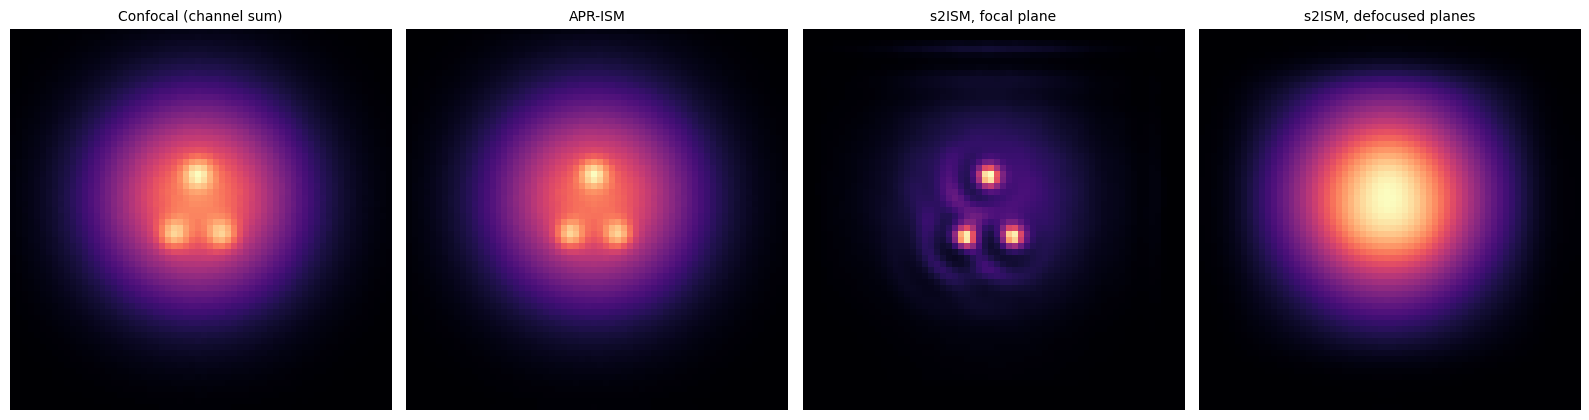

In [5]:
# Side by side. The haze is present in the confocal and APR images and is
# pushed into the defocused planes by s2ISM, leaving the beads behind.
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (title, img) in zip(axes, [
    ("Confocal (channel sum)", confocal),
    ("APR-ISM", apr),
    ("s2ISM, focal plane", focal_plane),
    ("s2ISM, defocused planes", out_of_focus),
]):
    ax.imshow(np.clip(img, 0, None), cmap="magma", origin="lower")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()